In [1]:
from google.colab import userdata
import os
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

ModuleNotFoundError: No module named 'google.colab'

In [22]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [23]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:10<00:00, 229MB/s]



In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [25]:
# Define image size and batch size
IMG_SIZE = 224
BATCH_SIZE = 64

In [26]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    '/content/data/chest_xray/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

Found 4173 images belonging to 2 classes.


In [27]:
val_generator = train_datagen.flow_from_directory(
    '/content/data/chest_xray/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 1043 images belonging to 2 classes.


In [28]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:
model.fit(
    train_generator,
    epochs=3,
    validation_data=val_generator
)

Epoch 1/3
66/66 ━━━━━━━━━━━━━━━━━━━━ 71s 940ms/step - accuracy: 0.8435 - loss: 0.4210 - val_accuracy: 0.9281 - val_loss: 0.1774
Epoch 2/3
66/66 ━━━━━━━━━━━━━━━━━━━━ 57s 857ms/step - accuracy: 0.9609 - loss: 0.1079 - val_accuracy: 0.9569 - val_loss: 0.1215
Epoch 3/3
66/66 ━━━━━━━━━━━━━━━━━━━━ 56s 851ms/step - accuracy: 0.9700 - loss: 0.0826 - val_accuracy: 0.9540 - val_loss: 0.1305


In [31]:
import os
os.makedirs('/content/model', exist_ok=True)
model.save('/content/model/PneumoniaDetector.h5')
print("Model saved!")

Model saved!


In [32]:
#Load your model
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt #visualisation
import numpy as np
model = load_model('/content/model/PneumoniaDetector.h5')
print("Model Loaded")

Model Loaded


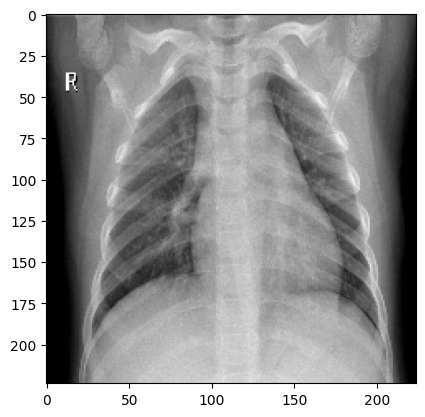

In [37]:
#load and view the test image
test_image_path="/content/data/chest_xray/train/NORMAL/IM-0127-0001.jpeg"
img=image.load_img(test_image_path,target_size=(224,224))
plt.imshow(img)
plt.axis()
plt.show()

In [38]:
# Preprocess the image
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.

# Make prediction
prediction = model.predict(img_array)
print(prediction)

if prediction[0][0] >= 0.5:
    print("Pneumonia detected.")
else:
    print("You do not have pneumonia.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[[0.00695226]]
You do not have pneumonia.
